# Gaussian fit
KA, Jan2026

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import os
import sys
import scanpy as sc
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

### Setup

In [13]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

base_dir = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/drg"

input_dir = os.path.join(base_dir, "data/h5ad/export_03/03b_seurat")

In [31]:
adata_path = os.path.join(base_dir, "data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad")
# adata_ref_path = os.path.join(base_dir, "data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad") # not available
adata_ref_path = os.path.join(base_dir, "data/h5ad/export_01/01b_filter/adata-480.h5ad") # try this instead

output_dir = os.path.join(base_dir, "data/h5ad/export_03/03b_thresholds")
if not os.path.exists (output_dir):
    os.makedirs(output_dir)

### Read and process adata
KA unable to locate adata_ref_path

In [32]:
adata_ref = sc.read_h5ad(adata_ref_path)
adata = sc.read_h5ad(adata_path)

In [33]:
adata_ref.shape

(72778, 480)

In [34]:
adata.shape

(72778, 475)

In [35]:
adata_list = [adata, adata_ref]

for ad in adata_list:
    ad.var_names = ad.var_names.where(ad.var_names != "tdTomato_Seq2", "dTomato_Seq2")

In [36]:
adata.X = adata.layers["counts"].copy()
adata_ref.X = adata_ref.layers["counts"].copy()

In [37]:
genes = ["EGFP_Seq1", "dTomato_Seq2"]

In [38]:
adata.var.shape

(475, 0)

In [42]:
sum(adata_ref.var.index.isin(["EGFP_Seq1", "dTomato_Seq2"]))

2

In [43]:
sum(adata_ref.var.index.str.lower().isin(["egfp_seq1", "dtomato_seq2"]))

2

In [69]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)


# Raw counts for filtering
egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
td_raw_all = to_dense(adata_ref[:, "dTomato_Seq2"].X)

# Filter to include only cells with >1 raw count in both genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# Fit a Gaussian distribution to filtered signal
for g in genes:
    x_raw_full = to_dense(adata_ref[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Fit Gaussian
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 * sd
    thr_log = mu + 2.326 * sigma
    
    # # 99.5th percentile of Gaussian = mean + 2.576 * sd
    # thr_log = mu + 2.576 * sigma
    
    # call positives
    hi_mask = np.zeros(adata_ref.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata_ref.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {"x_log": x_log, "thr_log": thr_log, "mu": mu, "sigma": sigma}

In [70]:
# Dual-high
adata_ref.obs["EGFP_dTomato_dual_hi"] = (
    adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
)

dual = adata_ref.obs["EGFP_dTomato_dual_hi"][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log = gauss_results["dTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log = gauss_results["dTomato_Seq2"]["thr_log"]

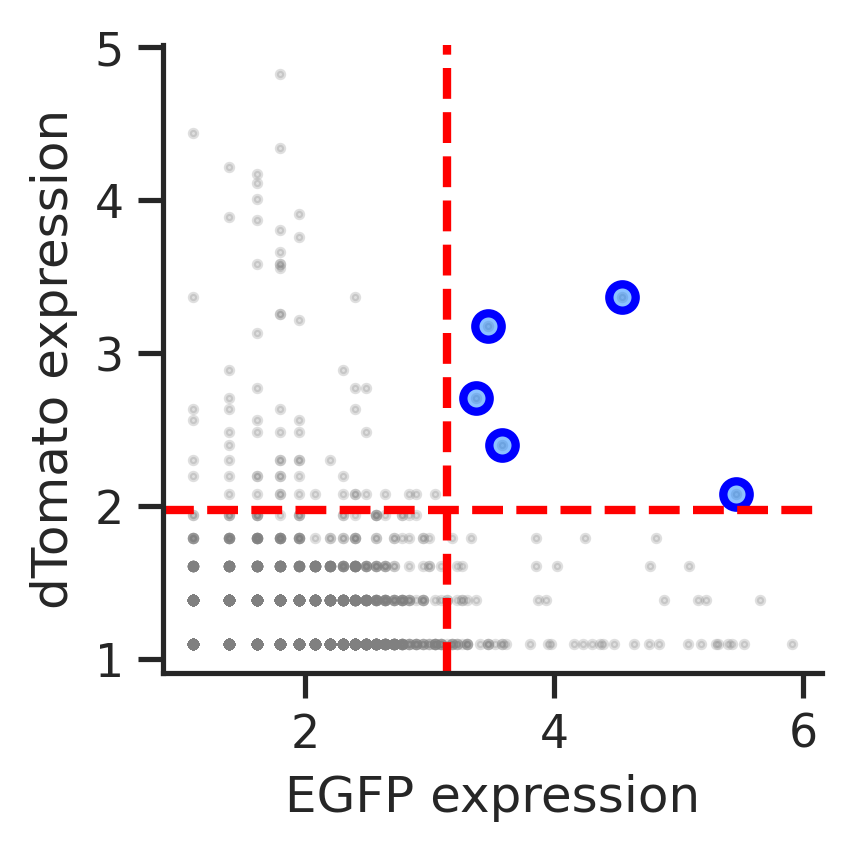

In [71]:
# Plot
sns.set_theme(style="ticks")

plt.figure(figsize=(3, 3), dpi=300)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=3, color="gray", alpha=0.25)
ax.scatter(
    x_egfp_log[dual],
    x_td_log[dual],
    s=40,
    facecolors=(0.0, 0.47, 1.0, 0.45),
    edgecolors="blue",
    linewidths=2,
)

ax.axvline(thr_egfp_log, color="red", ls="--", lw=2)
ax.axhline(thr_td_log, color="red", ls="--", lw=2)

ax.set_xlabel("EGFP expression")
ax.set_ylabel("dTomato expression")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [47]:
# Column-wise copy from ref_data to adata

adata.obs[["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]] = adata_ref.obs[
    ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]
].values

In [ ]:
for ad in adata_list:
    mask = ad.obs["EGFP_dTomato_dual_hi"].fillna(False)
    dual_barcodes = ad.obs.index[mask].tolist()

    print("\nDual-positive barcodes:")
    for bc in dual_barcodes:
        print(bc)
    print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")

In [74]:
adata_ref.obs['sample_id'].unique().tolist()

['TMA00317', 'TMA00315', 'TMA00318', 'TMA00316']

# Export

In [ ]:
# filename = os.path.join(output_dir, "adata-labeled.h5ad")
# os.makedirs(os.path.dirname(filename), exist_ok=True)

# adata.write_h5ad(filename, compression="gzip")